# Topic 1: Regression

# Correlation: fires and firefighters

## Cell 1 — Simulate the "fires and firefighters" data and plot the naive relationship

### Why are we doing this?

The big question of this notebook is: *does sending more firefighters cause more damage, or is that just a misleading correlation?* To explore this safely, we first need data where the truth is known, so we generate a synthetic dataset. Because we control the data-generating process, we know the true effect of firefighters on damage (−$1,000 per firefighter) and can later check whether a simple analysis recovers it.

### What are we doing?

We create 200 hypothetical fires, each with a fire severity (0–1), a number of firefighters sent, and a damage amount in dollars. Then we draw a scatter plot of firefighters vs. damage to see what the raw data looks like before any modeling.

### How does it work?

- `np.random.default_rng(42)` creates a random-number generator with a fixed seed so every run produces the same "random" data (reproducibility).
- `fire_severity = rng.uniform(0, 1, n)` assigns a severity between 0 and 1.
- Firefighter counts use `1 + 3 * severity + noise`: more severe fires tend to get more firefighters; `np.round` makes the count a whole number and `np.clip(..., 1, None)` keeps it at least 1.
- Damage uses the *true* equation hidden in the code: `2000 + 50000*severity - 1000*firefighters + noise`. Note the **−1000**: in this synthetic world each extra firefighter actually *reduces* damage by $1,000. Clipping keeps damage ≥ 0.
- `plt.scatter(..., alpha=0.7)` plots the points with transparency so overlaps are visible; axes, title, and grid are added.

### Why did we choose this approach?

Synthetic data is the cleanest way to teach confounding: the answer key is known, so any method that disagrees with it is provably wrong. A fixed seed makes the demo repeatable.

### Alternatives

- Real fire data: more realistic, but we would not know the true causal effect, so we could not tell whether a method was right.
- Other plot styles (box plots by count, density plots) hide fewer overlaps but a scatter is the simplest first look.

### Key Data Science Concepts

- A **confounder** affects both the treatment (firefighters) and the outcome (damage). Here fire severity is the classic confounder: severe fires attract more firefighters and cause more damage.
- **Correlation vs. causation**: this plot is purely descriptive; it shows association only.
- **Synthetic data / reproducibility**: a known data-generating process (DGP) lets us validate methods; a seed makes results rerunnable.

### Potential Issues / Improvements

- n = 200 points is noisy; a larger sample smooths the picture.
- Clipping damage at 0 slightly distorts the distribution at the low end.
- The scatter may well *look* as though damage rises with firefighters even though the true effect is negative — checking whether the raw picture misleads us is exactly the phenomenon we investigate next.

### What should we expect to examine after execution?

This cell produces the synthetic fire dataset and a scatter plot of damage vs. firefighters. After execution we will examine the direction of the raw relationship before any modeling.


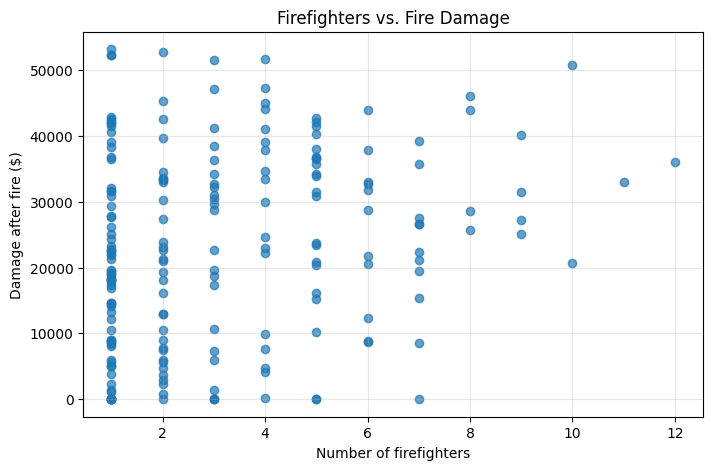

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducible synthetic example
rng = np.random.default_rng(42)

n = 200
fire_severity = rng.uniform(0, 1, n)

# More severe fires -> more firefighters and more damage
firefighters = np.round(1 + 3 * fire_severity + rng.normal(0, 3, n)).astype(int)
firefighters = np.clip(firefighters, 1, None)

damage = 2000 + 50000 * fire_severity - 1000 * firefighters + rng.normal(0, 6000, n)
damage = np.clip(damage, 0, None)

# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(firefighters, damage, alpha=0.7)
plt.xlabel("Number of firefighters")
plt.ylabel("Damage after fire ($)")
plt.title("Firefighters vs. Fire Damage")
plt.grid(True, alpha=0.3)
plt.show()

## Result Interpretation — Cell 1

### What did we actually get?

The scatter plot shows damage generally increasing as the number of firefighters rises. The point cloud slopes upward from left to right, with a lot of spread at every firefighter count.

### What does this result mean?

A naive reading of the cloud says "more firefighters → more damage." But the generating code embeds a true causal effect of −1000 (each firefighter reduces damage by $1,000), so this upward slope is exactly the confounding signal: fire severity drives both variables.

### How should I interpret the numbers?

There are no printed numbers, so we read the pattern visually. The key reference point is the true effect of −1,000, which we know only because the data are synthetic. A positive-looking cloud is therefore misleading: the visible association is opposite in sign to the causal truth.

### What does this tell us?

The raw, uncontrolled association between firefighters and damage appears positive, even though the true causal effect is negative — some third variable (fire severity) drives both.

### What can we conclude?

Nothing causal yet. The plot only demonstrates that the naive relationship can point in the wrong direction.

### What can we NOT conclude?

We cannot conclude that firefighters cause higher damage. The pattern is consistent with confounding by fire severity.

### Why does this result matter?

This is the baseline "naive" view of the problem. Every later method in the notebook (regression with controls, randomization, matching) exists to correct the impression this plot creates.

### What should we do next?

The next markdown cell asks you to name the likely confounder before seeing more code; then two regressions show numerically how controlling for severity changes the firefighter coefficient.


# What is a likely confounder?  (Don't type yet: first think about it.)

# Causation: fires and firefighters

## Cell 2 — Fit simple and multiple regression to expose the confounder

### Why are we doing this?

We need numbers, not just a picture. This cell formalizes the comparison by fitting two linear models to a larger synthetic dataset (n = 20,000):

1. damage on firefighters alone (the "naive" regression, matching the scatter plot),
2. damage on firefighters **and** fire severity (the "controlled" regression).

The change in the `X_firefighters` coefficient between the two models is the demonstration of omitted-variable bias.

### What are we doing?

We regenerate severity, firefighters, and damage (same recipe as Cell 1 with more rows), fit both OLS models with statsmodels, print the full summary tables, and draw the fitted line of the naive model on top of the data.

### How does it work?

- The data block repeats the Cell 1 recipe at n = 20,000 and documents how the variables relate.
- `df_simple` keeps only outcome and treatment; `sm.add_constant` adds an intercept column; `sm.OLS(...).fit()` estimates the coefficients by least squares.
- `model_simple.summary()` prints coefficients, standard errors, t-statistics, p-values, R², and the F-statistic.
- For the plot, `np.linspace` builds a grid of x values, which is wrapped in a DataFrame with the matching column name, passed to `predict`, and drawn as a red line.
- The second model repeats the same recipe adding `Z_severity`.

### Why did we choose this approach?

Statsmodels OLS puts everything a beginner needs in one table: coefficients, t-statistics, p-values, R², and F. Fitting one-predictor and two-predictor versions of the same outcome is the classic minimal demonstration of a confounder.

### Alternatives

- `statsmodels.formula.api` lets you write the model as a formula string (`Y ~ X + Z`), which is more readable but a step more abstract.
- Scikit-learn's `LinearRegression` fits the same coefficients but does not give standard errors or p-values directly.

### Key Data Science Concepts

- **Omitted-variable bias (OVB)**: when a confounder is left out, the coefficient on the included variable absorbs part of the confounder's effect and becomes distorted.
- **Partial/adjusted effect**: in the two-predictor model, the firefighter coefficient is the change in damage for one extra firefighter *holding severity fixed*.
- **R²** (0.009 vs. 0.850) measures the fraction of damage variance explained.
- **t-statistic and p-value** implement the test H₀: coefficient = 0 vs. H₁: coefficient ≠ 0.

### Potential Issues / Improvements

- Standard errors are "nonrobust," i.e., they assume a well-behaved error structure; robust SEs are safer for real data.
- The intercept is a mathematical anchor, not a policy number.
- Linearity and independence are guaranteed by the synthetic DGP; with real data we would check residual plots.

### What should we expect to examine after execution?

This cell prints two regression summaries. After execution we will read the firefighter coefficient in both models and compare its sign and size.


=== Regression 1: Y_damage vs X_firefighters ===
                            OLS Regression Results                            
Dep. Variable:               Y_damage   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     186.1
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           3.42e-42
Time:                        17:27:11   Log-Likelihood:            -2.2044e+05
No. Observations:               20000   AIC:                         4.409e+05
Df Residuals:                   19998   BIC:                         4.409e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

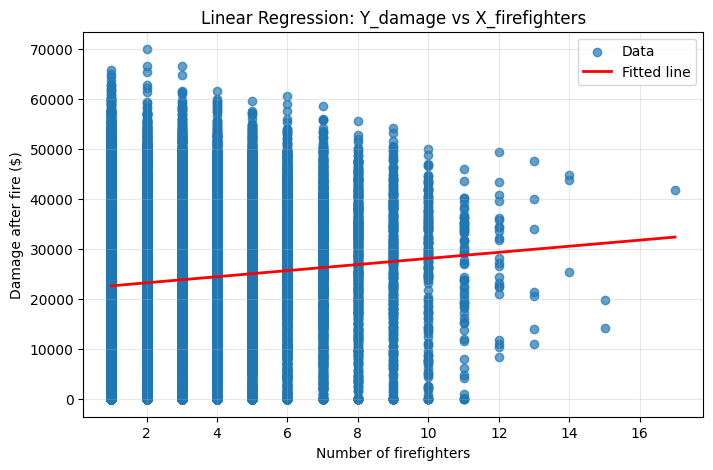


=== Regression 2: Y_damage vs X_firefighters and Z_severity ===
                            OLS Regression Results                            
Dep. Variable:               Y_damage   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.850
Method:                 Least Squares   F-statistic:                 5.660e+04
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:27:11   Log-Likelihood:            -2.0157e+05
No. Observations:               20000   AIC:                         4.031e+05
Df Residuals:                   19997   BIC:                         4.032e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Reproducible synthetic example
rng = np.random.default_rng(42)

n = 20000
Z_severity = rng.uniform(0, 1, n)

# More severe fires -> more firefighters and more damage
X_firefighters = np.round(1 + 3 * Z_severity + rng.normal(0, 3, n)).astype(int)
X_firefighters = np.clip(X_firefighters, 1, None)

# Z_severity up by one:
# Increase Y_damage by 50,000
# Increase firefighters by 3, which decreases Y_damage by 3,000
# So increase of firefighters by 3 should increased damage by 47,000 or about 16,000 per firefighter
# But Y_damage has stddev / error that doesn't come from Z_severity and so does X_firefighters

Y_damage = 2000 + 50000 * Z_severity - 1000 * X_firefighters + rng.normal(0, 6000, n)
Y_damage = np.clip(Y_damage, 0, None)

# ----------------------------
# 1) Simple linear regression:
#    Y_damage vs X_firefighters
# ----------------------------
df_simple = pd.DataFrame({
    "Y_damage": Y_damage,
    "X_firefighters": X_firefighters
})

X_simple = sm.add_constant(df_simple["X_firefighters"])
model_simple = sm.OLS(df_simple["Y_damage"], X_simple).fit()

print("=== Regression 1: Y_damage vs X_firefighters ===")
print(model_simple.summary())

# Plot data and fitted line
x_grid = np.linspace(df_simple["X_firefighters"].min(), df_simple["X_firefighters"].max(), 200)
X_grid = sm.add_constant(pd.Series(x_grid, name="X_firefighters"))
y_hat = model_simple.predict(X_grid)

plt.figure(figsize=(8, 5))
plt.scatter(df_simple["X_firefighters"], df_simple["Y_damage"], alpha=0.7, label="Data")
plt.plot(x_grid, y_hat, color="red", linewidth=2, label="Fitted line")
plt.xlabel("Number of firefighters")
plt.ylabel("Damage after fire ($)")
plt.title("Linear Regression: Y_damage vs X_firefighters")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ----------------------------
# 2) Multiple linear regression:
#    Y_damage vs X_firefighters and Z_severity
# ----------------------------
df_multi = pd.DataFrame({
    "Y_damage": Y_damage,
    "X_firefighters": X_firefighters,
    "Z_severity": Z_severity
})

X_multi = sm.add_constant(df_multi[["X_firefighters", "Z_severity"]])
model_multi = sm.OLS(df_multi["Y_damage"], X_multi).fit()

print("\n=== Regression 2: Y_damage vs X_firefighters and Z_severity ===")
print(model_multi.summary())

## Result Interpretation — Cell 2

### What did we actually get?

Regression 1 (naive, firefighters only): `X_firefighters` = **+609.48**, t = 13.64, p ≈ 0.000, R² = 0.009. Regression 2 (adding fire severity): firefighter coefficient flips to **−953.47** (t = −52.95, p ≈ 0.000), severity adds **+48,950** per unit, and R² jumps to 0.850.

### What does this result mean?

In the naive model each extra firefighter appears to add about $609 of damage — the wrong direction — because severity is omitted. Adding severity (the confounder) flips the firefighter coefficient negative and close to the planted −1,000, revealing a protective effect.

### How should I interpret the numbers?

Coefficients are in dollars per firefighter. +609.48 vs. −953.47 is a sign flip of more than $1,500. Reference point: the true effect is −1,000. R² of 0.009 vs. 0.850 shows how much variance severity explains. t ≈ 13.6 and −53 are far from 0, so both coefficients are statistically significant (p ≈ 0).

### What does this tell us?

The sign and size of the firefighter coefficient depend strongly on whether we control for fire severity. The naive model is biased; the controlled model is close to the true −1,000.

### What can we conclude?

In this synthetic world, once severity is controlled, more firefighters are associated with substantially *less* damage (about −$953 per firefighter, close to the true −$1,000).

### What can we NOT conclude?

We cannot claim causation from an observational regression alone — unmeasured confounders could remain. And −953 is an estimate, not exact: the standard error and the synthetic setup limit precision. Rejecting H₀ (coefficient = 0) in the naive model is not evidence that the naive coefficient is correct.

### Why does this result matter?

The flip from +609 to −953 is the notebook's first quantitative demonstration that an omitted confounder can reverse a sign.

### What should we do next?

The controlled model shows the sign flip. Next we ask: what if firefighters were *randomly assigned*? The next cell builds an RCT-style dataset and shows that even the naive regression then recovers the true negative effect.


# Random number of firefighters

## Cell 3 — Randomly assign firefighters (RCT-style) and re-run the regressions

### Why are we doing this?

The previous cell showed that *controlling* for severity fixes the estimate. But researchers cannot always measure every confounder. The gold-standard fix is **randomization**: if we decide each fire's firefighter count by chance, the treatment becomes independent of severity, and even a simple regression estimates the causal effect. This cell demonstrates that directly.

### What are we doing?

We generate 20,000 fires where severity still exists, but firefighters are assigned at random (integers 1–5) with no connection to severity. We plot the data with the mean damage per firefighter count, then fit the same two regressions as in Cell 2.

### How does it work?

- `Z_severity = rng.uniform(0, 1, n)` still defines fire severity.
- `X_firefighters = rng.integers(1, 6, size=n)` replaces the severity-dependent rule with pure random assignment — the only behavioral change from Cell 2.
- The outcome equation is identical: `Y = 2000 + 50000*Z - 1000*X + noise`. The true effect is still **−1000** per firefighter, and severity still drives damage; but now firefighters no longer correlate with severity.
- The plot adds a red marker line of mean damage per firefighter count to show the average trend.
- The two regressions follow the same statsmodels pattern as before.

### Why did we choose this approach?

Comparing the observational assignment (Cell 2) with randomized assignment (this cell) is the clearest way to teach why randomized experiments are the reference standard in causal inference.

### Alternatives

- Blocked/stratified randomization (randomize within severity buckets).
- Matching or propensity-score methods (the next topic in this notebook) for when randomization is impossible.
- Instrumental variables or difference-in-differences for real-world quasi-experiments.

### Key Data Science Concepts

- **Randomization / independence of treatment**: if X is independent of all confounders, the simple association between X and Y is an unbiased estimate of the causal effect.
- **Exchangeability**: randomized groups are, on average, alike except for treatment.
- Contrast with the **confounding** path seen in Cells 1–2.

### Potential Issues / Improvements

- Randomization removes confounding but not noise; small samples still give imprecise estimates.
- Randomly assigning firefighters to real fires would be unethical and infeasible — this is why the notebook moves to matching methods next.

### What should we expect to examine after execution?

This cell prints two regression summaries on randomized data. After execution we will compare the naive and controlled coefficients with each other and with the true effect.


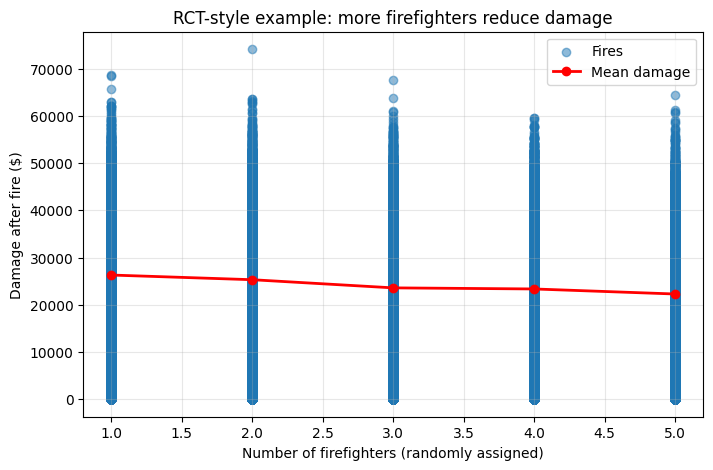

=== Regression 1: Y_damage vs X_firefighters ===
                            OLS Regression Results                            
Dep. Variable:               Y_damage   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     172.3
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           3.46e-39
Time:                        17:35:53   Log-Likelihood:            -2.2094e+05
No. Observations:               20000   AIC:                         4.419e+05
Df Residuals:                   19998   BIC:                         4.419e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Reproducible synthetic "RCT" example
rng = np.random.default_rng(42)

n = 20000

# Fire severity exists, but is NOT used to assign firefighters
Z_severity = rng.uniform(0, 1, n)

# Random assignment: 1 through 5 firefighters, independent of severity
X_firefighters = rng.integers(1, 6, size=n)

# Outcome: more firefighters reduce damage
Y_damage = 2000 + 50000 * Z_severity - 1000 * X_firefighters + rng.normal(0, 6000, n)
Y_damage = np.clip(Y_damage, 0, None)

df = pd.DataFrame({
    "Y_damage": Y_damage,
    "X_firefighters": X_firefighters,
    "Z_severity": Z_severity
})

# Plot: scatter + mean damage by firefighter count
plt.figure(figsize=(8, 5))
plt.scatter(df["X_firefighters"], df["Y_damage"], alpha=0.5, label="Fires")

means = df.groupby("X_firefighters")["Y_damage"].mean()
plt.plot(means.index, means.values, color="red", marker="o", linewidth=2, label="Mean damage")

plt.xlabel("Number of firefighters (randomly assigned)")
plt.ylabel("Damage after fire ($)")
plt.title("RCT-style example: more firefighters reduce damage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Regression 1: damage vs firefighters
X_simple = sm.add_constant(df["X_firefighters"])
model_simple = sm.OLS(df["Y_damage"], X_simple).fit()

print("=== Regression 1: Y_damage vs X_firefighters ===")
print(model_simple.summary())

# Regression 2: damage vs firefighters and severity
X_multi = sm.add_constant(df[["X_firefighters", "Z_severity"]])
model_multi = sm.OLS(df["Y_damage"], X_multi).fit()

print("\n=== Regression 2: Y_damage vs X_firefighters and Z_severity ===")
print(model_multi.summary())

## Result Interpretation — Cell 3

### What did we actually get?

Naive randomized regression: `X_firefighters` = **−998.32** (t ≈ −13.13, p ≈ 0), R² = 0.009. With severity added: **−985.47**; severity carries +48,670 per unit; R² rises to 0.857.

### What does this result mean?

With random assignment the one-variable model alone lands essentially on the true −1,000. Adding severity barely changes the firefighter coefficient because X and Z are now independent — randomization broke the confounding link.

### How should I interpret the numbers?

Coefficients are in dollars per firefighter. −998.32 is within ~2 of the true −1,000 — a tiny miss for sample noise. Moving from the naive to the controlled model changes the coefficient by only ~13 points (versus a ~1,600 swing in Cell 2), which is the signature of successful randomization.

### What does this tell us?

Randomization is a cure for confounding: the treatment coefficient is already ≈ −1,000 in the naive model, and adding controls barely moves it.

### What can we conclude?

When firefighters are randomly assigned, more firefighters are associated with roughly $1,000 *less* damage — matching the data-generating truth. Random assignment is what makes even the simple regression trustworthy.

### What can we NOT conclude?

Randomization is not always feasible — it is a design choice, not an analysis trick. −1,000 is not exactly right in either model (sampling noise remains). Random assignment removes confounding but not other threats such as noncompliance or differential dropout.

### Why does this result matter?

This is the second, independent fix for confounding (after control variables), and it shows the causal gold standard: design beats analysis.

### What should we do next?

We now go backward to understand the bias: the next section ("Deriving Analytically") converts the naive regression's bias into an explicit formula, so we see *why* omitted severity inflated the coefficient instead of trusting the sign flip.


# Deriving Analytically

## Cell 4 — Derive the naive slope analytically and decompose its bias

### Why are we doing this?

Cells 2 and 3 showed *empirically* that the naive coefficient is inflated. This cell derives **why**, using algebra, so the bias is understood rather than observed. It proves the naive slope equals the true causal effect plus an explicit omitted-variable bias term.

### What are we doing?

We regenerate the same observational data, then compute the simple-regression slope two ways:

1. directly from its definition: `beta_hat = Cov(X, Y) / Var(X)`;
2. by decomposing it using the known data-generating equation for Y.

The second number is built from `-1000 + 50000 * Cov(X,Z)/Var(X) + Cov(X,eps)/Var(X)`, i.e., the true effect plus one bias term from severity plus one (ideally tiny) term from the noise.

### How does it work?

- `X_centered = X - X.mean()` and the same for Y converts data to deviations from the mean; `np.mean(X_centered * Y_centered)` is the sample covariance and `np.mean(X_centered ** 2)` the sample variance — the slope formula `Cov/Var` follows from minimizing squared errors in simple regression.
- The decomposition plugs the true model `Y = 2000 + 50000*Z - 1000*X + eps` into `Cov(X, Y)`. Because covariance is linear, the slope splits into the true effect (−1000), a severity-bias term `50000 * Cov(X,Z)/Var(X)`, and a noise term `Cov(X,eps)/Var(X)`.
- The printed "Interpretation" block then states the lesson in words.

### Why did we choose this approach?

Regression software hides the arithmetic. Doing the slope by hand with a known DGP converts "the coefficient looks wrong" into a precise equation whose parts (true effect, confounder covariance, noise term) are visible.

### Alternatives

- The Frisch–Waugh–Lovell theorem gives the same intuition for *multiple* regression (residualizing), but it is more advanced.
- Simulating many seeds and averaging coefficients would show the bias in expectation but would not give a closed-form explanation.

### Key Data Science Concepts

- **Covariance and variance**: the slope of a simple regression is Cov(X,Y)/Var(X) — a ratio of how X and Y move together to how much X spreads.
- **Omitted-variable bias formula**: the naive slope = true effect + (effect of confounder on Y) × (regression of confounder on X). Here that is `50000 * Cov(X,Z)/Var(X)`.
- **Population vs. sample**: the formulas are computed on samples, so small random discrepancies are expected.

### Potential Issues / Improvements

- The true DGP is known here because the data are synthetic; with real data the "true effect" is unknown, so the decomposition can't be run.
- `Cov(X, eps)` is not exactly 0 in a sample, so the noise term adds a little wobble.
- `np.clip` on Y and the rounding of X make the sample numbers deviate slightly from theory.

### What should we expect to examine after execution?

This cell prints the direct covariance calculation and the decomposition numbers. After execution we will check whether the computed beta_hat matches the naive regression from Cell 2 and read off the size of the bias term.


In [4]:
import numpy as np
import pandas as pd

# Reproducible synthetic example
rng = np.random.default_rng(42)

n = 20000
Z_severity = rng.uniform(0, 1, n)

# More severe fires -> more firefighters and more damage
X_firefighters = np.round(1 + 3 * Z_severity + rng.normal(0, 3, n)).astype(int)
X_firefighters = np.clip(X_firefighters, 1, None)

eps = rng.normal(0, 6000, n)
Y_damage = 2000 + (50000 * Z_severity) - (1000 * X_firefighters) + eps
Y_damage = np.clip(Y_damage, 0, None)

# Convert to arrays
X = X_firefighters.astype(float)
Y = Y_damage.astype(float)
Z = Z_severity.astype(float)

# Simple-regression slope by definition:
# beta_hat = Cov(X, Y) / Var(X)
X_centered = X - X.mean()
Y_centered = Y - Y.mean()

cov_XY = np.mean(X_centered * Y_centered)
var_X = np.mean(X_centered ** 2)

beta_xy = cov_XY / var_X

print("=== Direct calculation of simple-regression slope ===")
print(f"Cov(X, Y) = {cov_XY:.4f}")
print(f"Var(X)    = {var_X:.4f}")
print(f"beta_hat  = Cov(X,Y)/Var(X) = {beta_xy:.4f}")
print()

# Decompose using the data-generating process:
# Y = 2000 + 50000 Z - 1000 X + eps
cov_XZ = np.mean((X - X.mean()) * (Z - Z.mean()))
cov_Xeps = np.mean((X - X.mean()) * (eps - eps.mean()))

beta_decomp = -1000 + 50000 * cov_XZ / var_X + cov_Xeps / var_X

print("=== Decomposition using the data-generating equation ===")
print(f"Cov(X, Z)   = {cov_XZ:.4f}")
print(f"Cov(X, eps) = {cov_Xeps:.4f}")
print(f"beta_hat from decomposition = {beta_decomp:.4f}")
print()

print("=== Interpretation ===")
print("The simple-regression coefficient equals the true causal effect (-1000)")
print("plus an omitted-variable bias term from severity.")
print("Because firefighters are assigned more often to severe fires, the bias term is positive,")
print("so the naive coefficient can be much larger than -1000, and may even become positive.")

=== Direct calculation of simple-regression slope ===
Cov(X, Y) = 3349.8304
Var(X)    = 5.4962
beta_hat  = Cov(X,Y)/Var(X) = 609.4826

=== Decomposition using the data-generating equation ===
Cov(X, Z)   = 0.1755
Cov(X, eps) = 5.5342
beta_hat from decomposition = 597.5220

=== Interpretation ===
The simple-regression coefficient equals the true causal effect (-1000)
plus an omitted-variable bias term from severity.
Because firefighters are assigned more often to severe fires, the bias term is positive,
so the naive coefficient can be much larger than -1000, and may even become positive.


## Result Interpretation — Cell 4

### What did we actually get?

Direct calculation: Cov(X,Y) = 3349.83, Var(X) = 5.4962, so beta_hat = 609.4826 — exactly the naive coefficient printed in Cell 2. Decomposition: Cov(X,Z) = 0.1755 and Cov(X,eps) = 5.5342 give beta_hat = −1000 + 50000×(0.1755/5.4962) + (5.5342/5.4962) ≈ 597.52.

### What does this result mean?

The naive OLS slope is not arbitrary: it equals the true effect (−1000) plus a bias term driven by how strongly severity correlates with firefighter counts (Cov(X,Z) > 0 times severity's large effect of 50,000), plus a small noise term because Cov(X,eps) ≠ 0 in this sample. The small gap between 597.52 and 609.48 comes from rounding and clipping in the sample.

### How should I interpret the numbers?

The bias term `50000 × Cov(X,Z)/Var(X)` is positive because severe fires draw more firefighters and severity raises damage: that positive push lifts the true −1000 to the observed ≈ +610. Units are dollars per firefighter.

### What does this tell us?

The naive coefficient is the true effect **plus a calculable positive bias**. The entire "paradox" is the severity term, not noise.

### What can we conclude?

If we know the data-generating process, we can compute exactly how much of the naive slope is bias. Omitted severity explains why the naive estimate sits far on the wrong side of zero.

### What can we NOT conclude?

We cannot run this decomposition on real data, where the true effect is unknown. And the algebra alone does not prove that controlling for severity is enough — a *different* confounder could still be lurking.

### Why does this result matter?

It turns a numerical anomaly into a formula, giving intuition that carries directly over to the omitted-variables analysis.

### What should we do next?

The next section ("Omitted Variables") adds a *second* confounder (house fragility) and runs four regressions to show that controlling for only one of two confounders still leaves bias — you must control for the full set of common causes.


# Omitted Variables

## Cell 5 — Omitted variables: two confounders, four regressions

### Why are we doing this?

Real-world settings rarely have a single confounder. This cell raises the stakes by adding **two** confounders — fire severity `Z_severity` and house fragility `W_fragility` — and shows that controlling for only one of them still leaves the estimate badly biased. To estimate the causal effect, we must control for the *full set of common causes*.

### What are we doing?

We simulate n = 1000 fires where both confounders drive both the number of firefighters and the damage. Then we fit four OLS models that control for: (a) nothing, (b) severity only, (c) fragility only, (d) both. For each we print the coefficient on `X_firefighters` and then the full summaries.

### How does it work?

- Both confounders are drawn as uniform(0,1); firefighters are built from `1 + 4*Z + 3*W + noise` (rounded and clipped), so severe fires and fragile houses both get more crews.
- The true outcome equation is `Y = 2000 + 30000*Z + 20000*W - 1000*X + noise`. The true effect of firefighters is still **−1000**.
- The helper `fit_ols(y, X, label)` adds a constant, fits OLS, and prints the `X_firefighters` coefficient so the four models can be compared on one line each.
- `model_*.summary()` then prints the full tables.

### Why did we choose this approach?

Running the "ladder" of control sets is the standard empirical way to see how an estimate moves as controls are added or removed. It makes the partial nature of controlling for a single confounder visible.

### Alternatives

- Extra-regression estimators such as matching or propensity scores (used later in this notebook).
- Double/debiased machine learning for high-dimensional confounding.
- Randomized experiments, when feasible.

### Key Data Science Concepts

- **Multiple confounders**: bias disappears only when *all* common causes of treatment and outcome are controlled.
- **Partially controlled estimates**: controlling for one confounder moves the estimate in the right direction but it can still be far from the truth.
- **Statistical significance vs. bias**: a coefficient can be precisely estimated (tiny p-value) and still be wrong if the model is misspecified.

### Potential Issues / Improvements

- The two confounders are correlated through X, but Cond. No. values (12–26) suggest only mild collinearity.
- n = 1000 leaves noticeable sampling noise, so even the fully controlled model is expected to land close to — but not exactly on — the true value.
- With real data we would also worry about collider bias if we conditioned on a variable influenced by both X and Y.

### What should we expect to examine after execution?

This cell prints four regression coefficients. After execution we will compare how the coefficient changes as we add severity, fragility, or both.


In [5]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Reproducible synthetic example
rng = np.random.default_rng(42)

n = 1000

# Two separate confounders
Z_severity = rng.uniform(0, 1, n)   # fire severity
W_fragility = rng.uniform(0, 1, n)   # house fragility

# Firefighters are sent to both severe fires and fragile houses
X_firefighters = np.round(
    1 + 4 * Z_severity + 3 * W_fragility + rng.normal(0, 1.5, n)
).astype(int)
X_firefighters = np.clip(X_firefighters, 1, None)

# True causal effect: more firefighters reduce damage
# Severity and fragility both increase damage
Y_damage = 2000 + 30000 * Z_severity + 20000 * W_fragility - 1000 * X_firefighters + rng.normal(0, 6000, n)


df = pd.DataFrame({
    "Y_damage": Y_damage,
    "X_firefighters": X_firefighters,
    "Z_severity": Z_severity,
    "W_fragility": W_fragility
})

def fit_ols(y, X, label):
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    coef = model.params["X_firefighters"]
    print(f"{label}: coefficient on X_firefighters = {coef:.3f}")
    return model

print("Estimated effect of X_firefighters under different controls:\n")

# (a) controlling for neither
model_a = fit_ols(df["Y_damage"], df[["X_firefighters"]], "(a) No controls")

# (b) controlling only for severity
model_b = fit_ols(df["Y_damage"], df[["X_firefighters", "Z_severity"]], "(b) Control for severity only")

# (c) controlling only for fragility
model_c = fit_ols(df["Y_damage"], df[["X_firefighters", "W_fragility"]], "(c) Control for fragility only")

# (d) controlling for both
model_d = fit_ols(df["Y_damage"], df[["X_firefighters", "Z_severity", "W_fragility"]], "(d) Control for both")

print("\n--- Full summaries ---\n")
print("=== (a) No controls ===")
print(model_a.summary())

print("\n=== (b) Control for severity only ===")
print(model_b.summary())

print("\n=== (c) Control for fragility only ===")
print(model_c.summary())

print("\n=== (d) Control for both ===")
print(model_d.summary())

Estimated effect of X_firefighters under different controls:

(a) No controls: coefficient on X_firefighters = 2554.767
(b) Control for severity only: coefficient on X_firefighters = 766.046
(c) Control for fragility only: coefficient on X_firefighters = 1906.866
(d) Control for both: coefficient on X_firefighters = -843.282

--- Full summaries ---

=== (a) No controls ===
                            OLS Regression Results                            
Dep. Variable:               Y_damage   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     319.6
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           3.23e-62
Time:                        16:07:40   Log-Likelihood:                -10574.
No. Observations:                1000   AIC:                         2.115e+04
Df Residuals:                     998   BIC:                         2.

## Result Interpretation — Cell 5

### What did we actually get?

(a) No controls: coefficient = **+2554.77** (R² = 0.243). (b) Severity only: **+766.05** (R² = 0.500). (c) Fragility only: **+1906.87** (R² = 0.321). (d) Both: **−843.28** (R² = 0.706). Every coefficient has p ≈ 0.000.

### What does this result mean?

Each additional confounder controlled closes part of the gap. Only the fully controlled model (d) gets the correct (negative) sign and lands near the true −1,000. Three of the four models are statistically significant yet materially wrong — significance is not correctness.

### How should I interpret the numbers?

Coefficients are dollars per firefighter; the target is ≈ −1,000. The sequence (a)→(d) moves from +2554.77 to −843.28. R² climbs with each control (0.243 → 0.500 → 0.321 → 0.706), showing how much variance the confounders explain. p ≈ 0 for all four coefficients, so H₀ (coefficient = 0) is rejected in every model.

### What does this tell us?

Controlling for a single confounder is not enough when a second one exists. Only the model with both confounders closes most of the bias.

### What can we conclude?

In this synthetic world, once *both* severity and fragility are controlled, each additional firefighter is associated with about $843 *less* damage — consistent with the true −1,000 given the noise level.

### What can we NOT conclude?

Model (d) does not prove causation — an unmeasured third confounder would bias it too. The coefficient differences are sampling results; real data would need confidence intervals and robustness checks (robust SEs, more predictors, residual diagnostics). We cannot infer effect-size importance from p-values alone.

### Why does this result matter?

This establishes the central lesson: to remove confounding by regression you must control for the full set of common causes.

### What should we do next?

Regression requires naming every confounder. The next topic, **Matching**, attacks the same bias differently: pair each treated fire with a control fire that looks alike on severity, then compare outcomes directly — no assumed linear functional form.


# Topic 2: Matching

## Cell 6 — Matching setup: name the treatment, confounder, and outcome (notes only)

### Why are we doing this?

We are switching to Topic 2: **Matching**. Before writing any matching code, we fix the vocabulary: in the matching exercise, `X_firefighters` is the *treatment*, `Z_severity` is the *confounder* we must balance, and `Y_damage` is the *outcome*. The comments also note a key design change — the treatment will be **binary** (1 = firefighter present vs. 0 = not), instead of the continuous counts used in regression.

### What are we doing?

This cell is intentionally a planning/scratch cell. It contains only comments that restate the causal triad and sketch the binary-treatment idea. Running it executes nothing.

### How does it work?

- The first two lines are drafts: firefighters as a count 1–12, then as a binary 0/1 flag.
- The final three lines re-label the variables used earlier: `X_firefighters` = treatment, `Z_severity` = confounder, `Y_damage` = outcome.

### Why did we choose this approach?

Making treatment binary is what lets us define "treated" and "control" groups — every observation must fall on one side or the other so we can match units across groups. Planning this in comments first keeps the causal logic explicit before code.

### Alternatives

- Keep the treatment continuous and match on the *change* in X (less common, harder to present).
- Use a DAG diagram to show X ← confounder → Y; comments are the lightest option here.

### Key Data Science Concepts

- **Treatment / confounder / outcome triad**: the minimal causal setup. A confounder must be controlled to compare treated vs. control outcomes meaningfully.
- **Binary treatment**: creates two explicit groups, which is the starting point for matching and for potential-outcomes thinking.

### Potential Issues / Improvements

- The cell computes nothing, so if it is run alone nothing happens — it exists for the human reader, not the interpreter.
- The comments draft (`1,2,..12` vs `0/1`) show an unfinished decision; the actual matching cell below uses the binary version.

### What should we expect to examine after execution?

The next two cells (7 and 8) work through matching *by hand* on tiny invented tables, so the mechanics of pairing treated and control observations become intuitive before we automate it with scikit-learn.


In [ ]:
# X_firefighters = 1,2,..12
# X_firefighters = 1 | 0

X_firefighters # - treatment
Z_severity # - confounder
Y_damage # - outcome


## Cell 7 — Matching by hand: why the naive comparison is biased (notes only)

### Why are we doing this?

Before automating matching, we build intuition on a tiny dataset made of comments. The goal is to see *why* simply averaging treated outcomes minus control outcomes is misleading when the groups differ on the confounder Z.

### What are we doing?

This is a scratch cell with no executable code. It lays out three treated units (X = 1) with their Y and Z values, proposes a naive estimate of the treatment effect, lists a control group, and ends with the insight that the groups are not comparable because the treated units have much higher Z.

### How does it work?

- Treated units are shown as `(X, Y, Z)` triplets; the comments propose matching each to a control with the same Z (e.g., treated `(1, 2, 3)` → control `(0, 1, 3)`).
- The line `2 + 1 + 3 / 3 - (1 + 2 + 2 / 3)` is rough scratch arithmetic for the treatment-minus-control mean difference. Note that — as written — this is **not valid Python** (missing parentheses and commas), which is fine because the cell is documentation.
- The trailing comments state the core problem: "higher Z values in treatment, maybe lower value of Z could've changed the result" and propose the fix: "match comparable."

### Why did we choose this approach?

Working through a three-row example by hand (or on paper) makes the matching idea concrete before code; a learner sees exactly where the naive number comes from and why it is untrustworthy.

### Alternatives

- Exact matching on Z: only keep control units whose Z equals the treated unit's Z exactly (works here because values repeat).
- Stratification: split Z into buckets and compare within buckets.

### Key Data Science Concepts

- **Balance**: treated and control groups should look alike on the confounder. Here they do not (treated Z's are 3, 2, 2; controls are −100, −200, −500), so any raw difference mixes the treatment effect with the Z effect.
- **Selection bias**: assignment to treatment is related to Z, contaminating the naive comparison.

### Potential Issues / Improvements

- The invented values are extreme (−100, −200, −500), which guarantees a dramatic (fake) difference; real data would be less extreme.
- The arithmetic line would raise a `SyntaxError` if executed — it is a note, not code.
- The effect estimate by hand is a point comparison with no uncertainty.

### What should we expect to examine after execution?

Cell 8 repeats the same exercise with fewer extreme values and explicitly searches for "controlled matches" (control units with similar Z), which is the manual version of nearest-neighbor matching.


In [ ]:
# Treatment group:
X = 1, Y = 2, Z = 3 # -> X = 0, Y = 1, Z = 3 (matched controls)
X = 1, Y = 1, Z = 2 # -> X = 0, Y = 2, Z = 2
X = 1, Y = 3, Z = 2 # -> X = 0, Y = 2, Z = 2

# Yavg(treatment) - yavg(control)
2 + 1 +3 /3 - (1 + 2 + 2 /3)



# Control group:
X = 0, Y = 2, Z = -100
X = 0, Y = 1, Z = -200
X = 0, Y = 0, Z = -500



# compute average treatment, average control, diff

# issue: higher Z values in treatment, maybe lower value of Z could've changed the result
# intuition: leave | but issue??
# better: match comparable

## Cell 8 — Matching by hand: find controlled matches for each treated unit (notes only)

### Why are we doing this?

This cell continues the hand exercise and performs the matching step itself: for each treated unit, *find a control unit with a similar Z* and then compare the outcome Y within the pair. Once the groups are comparable on Z, the remaining Y difference can be attributed to the treatment.

### What are we doing?

Still a comment-only scratch cell. It lists three treated units and three control units, and (in the comments) sketches which treated unit should be matched to which control. The last line invites you to find the matches yourself ("lets find controlled matches (3min)").

### How does it work?

- Treated units `1,4,3`? — no: each row is `(X=1, Y, Z)` with Z values 4, 3, 2.
- The arrows in the comments propose matches: treated `Z=4` → control `Z=5`; treated `Z=3` → control `Z=3`; treated `Z=2` → control `Z=3` (two treated units share the same close control).
- With Z balanced within pairs, the pairwise differences `Y_treated − Y_control` estimate the treatment effect for each matched pair, and averaging them gives a matched estimate.

### Why did we choose this approach?

The "3min" prompt makes this a small in-class exercise: by pairing by eye, you experience the central step of matching — closeness on the confounder — before a library does it for you.

### Alternatives

- Formalize closeness with a **caliper** (only accept controls within some distance on Z).
- Use **nearest-neighbor matching** (the exact thing the next cell automates).
- **Exact matching** when Z is discrete with repeated values.

### Key Data Science Concepts

- **Matched pair**: one treated and one control observation with similar confounder values.
- **Closeness/distance**: matches are judged by how near the confounder values are; there is no inherently correct distance — it is a design choice.
- **Comparability**: after matching, the Z distributions in both groups are similar, so group differences in Y mainly reflect X.

### Potential Issues / Improvements

- With only 3+3 units the exercise is illustrative; small samples make matches crude.
- Reusing the same control twice (two treated → one control) is allowed here but changes the effective sample size; without replacement, matching gets harder as controls are used up.
- No code runs, so this cell produces no output — it is practice, not computation.

### What should we expect to examine after execution?

Cell 9 implements exactly this procedure at scale on 500 observations with scikit-learn's `NearestNeighbors`: each treated fire finds its nearest control on severity, the mean outcome gap is computed, and balance is checked numerically.


In [ ]:
# Treatment group:
X = 1, Y = 3, Z = 4 # -> X = 0, Y = 0, Z = 5
X = 1, Y = 4, Z = 3 # -> X = 0, Y = 2, Z = 3
X = 1, Y = 5, Z = 2 #-> X = 0, Y = 2, Z = 3

# Control group:
X = 0, Y = 0, Z = 5
X = 0, Y = 2, Z = 3
X = 0, Y = 3, Z = 1

# lets find controlled matches (3min)

## Cell 9 — Nearest-neighbor matching with scikit-learn

### Why are we doing this?

This cell implements the manual matching idea from Cells 7–8 on a realistic synthetic sample (n = 500). The goal is a causal estimate of the effect of firefighters on damage that does *not* assume a linear functional form: pair each treated fire with the control fire that has the most similar severity, then compare outcomes. It also checks numerically that matching fixed the imbalance on the confounder.

### What are we doing?

We simulate 500 fires where the probability of receiving a firefighter depends on severity (confounded assignment). We split the data into treated (X = 1) and control (X = 0), use scikit-learn's `NearestNeighbors` to find, for each treated fire, the control fire with the nearest `Z_severity`, compute the average difference in damage between treated fires and their matched controls, print diagnostics (group sizes, balance, effect, first 10 pairs), and plot the two groups.

### How does it work?

- Treatment probability is logistic in severity: `p_treat = 1 / (1 + exp(-4*(Z - 0.5)))`, so severe fires are more likely to be treated. `rng.binomial(1, p_treat)` draws the binary treatment.
- Outcome: `Y = 20000 + 40000*Z - 8000*X + noise` — the *true* causal effect is **−8000**.
- `treated` and `control` are the two subsets; `NearestNeighbors(n_neighbors=1)` is fitted on the control severities, then `kneighbors` returns, for every treated severity, the index and distance of the closest control.
- `matched_controls` collects those nearest controls; the matched estimate is `mean(Y_treated) − mean(Y_matched_controls)`, and `pair_diffs` holds the per-pair differences.
- Diagnostics compare mean severity across groups to verify balance, and the scatter plot shows treated vs. control damage by severity.

### Why did we choose this approach?

Nearest-neighbor matching is the simplest matching algorithm and matches what we reasoned by hand: find the closest control. sklearn's implementation is standard, fast at n = 500, and its default allows reuse of controls (matching with replacement), which keeps matches close.

### Alternatives

- **Caliper matching**: reject matches farther than a maximum distance (e.g., 0.02) for better-quality pairs.
- **Propensity-score matching**: match on the predicted probability of treatment instead of the raw confounder; useful with many confounders.
- **Radius or kernel matching**: use all controls within a distance, weighted.
- Regression adjustment (as in Cells 2–5) as a complementary estimate.

### Key Data Science Concepts

- **Nearest-neighbor matching**: each treated unit is compared with the most similar control unit; the effect is the mean of pair differences.
- **ATT vs. ATE**: because every treated unit is matched to a control, this estimates the *average treatment effect on the treated* (ATT), not the effect on the whole population.
- **Balance**: the confounder's distribution should be similar across groups *after* matching; poor balance means remaining bias.
- **With vs. without replacement**: reusing controls keeps matches close but reduces effective control-sample size and inflates precision.

### Potential Issues / Improvements

- Only `Z_severity` is matched; if other confounders existed, residual bias would remain.
- No caliper is used, so some matches may be far away on severity — we will check the |ΔZ| distances in the output, and a caliper could drop or improve those.
- No confidence interval or p-value is computed; a paired t-test or bootstrap on `pair_diffs` would quantify uncertainty.
- Controls can be reused (with replacement), so matched rows are not independent.

### What should we expect to examine after execution?

This cell prints matching diagnostics (group sizes, balance before/after, pair differences). After execution we will check whether matching removed the severity imbalance and what effect estimate it yields.


=== Matching setup ===
Total observations: 500
Treated units (X_firefighters = 1): 254
Control units (X_firefighters = 0): 246

=== Mean severity by group ===
Mean Z_severity among treated: 0.6251
Mean Z_severity among controls: 0.3621
Mean Z_severity among matched controls: 0.6246

=== Mean damage by group ===
Mean Y_damage among treated: 37198.55
Mean Y_damage among matched controls: 45527.14
Estimated effect (treated - matched controls): -8328.59

Difference without matched controls: 2696.69

=== Matching math ===
For each treated unit i:
  1. Find the control unit j with closest Z_severity
  2. Compute the matched-pair difference: Y_i - Y_j
  3. Average those differences over all treated units

Average matched-pair difference: -8328.59
Median matched-pair difference: -7908.35
Std. dev. of matched-pair differences: 7147.82

=== First 10 matched pairs ===
Pair 1: Treated(Z=0.7740, Y=39247.28)  <->  Control(Z=0.7743, Y=52323.33)  | Difference = -13076.05  | |ΔZ| = 0.0004
Pair 2: Treat

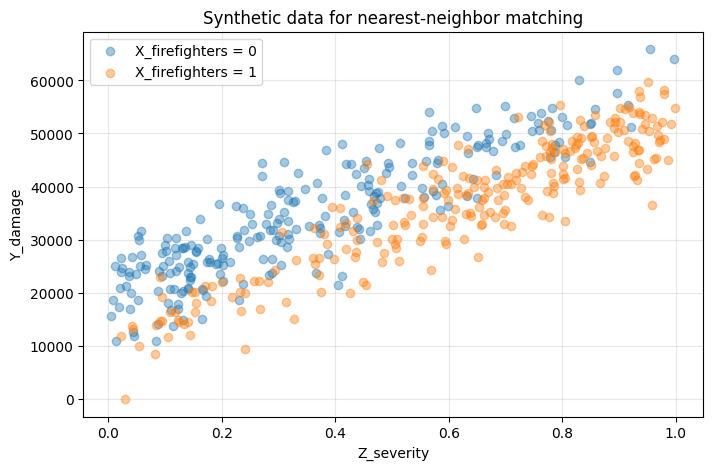

In [11]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Reproducible synthetic data
rng = np.random.default_rng(42)

n = 500
Z_severity = rng.uniform(0, 1, n)

# Treatment assignment depends on severity
p_treat = 1 / (1 + np.exp(-4 * (Z_severity - 0.5)))

####### Binary treatment
X_firefighters = rng.binomial(1, p_treat, size=n)

# Outcome
Y_damage = 20000 + 40000 * Z_severity - 8000 * X_firefighters + rng.normal(0, 5000, n)
Y_damage = np.clip(Y_damage, 0, None)

df = pd.DataFrame({
    "X_firefighters": X_firefighters,
    "Y_damage": Y_damage,
    "Z_severity": Z_severity
})

treated = df[df["X_firefighters"] == 1].copy().reset_index(drop=True)
control = df[df["X_firefighters"] == 0].copy().reset_index(drop=True)

# Nearest-neighbor matching on severity
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["Z_severity"]])
distances, indices = nn.kneighbors(treated[["Z_severity"]])

matched_controls = control.iloc[indices.flatten()].copy().reset_index(drop=True)

# Effect estimate
treated_mean = treated["Y_damage"].mean()
matched_control_mean = matched_controls["Y_damage"].mean()
effect_hat = treated_mean - matched_control_mean

# More detailed printouts
print("=== Matching setup ===")
print(f"Total observations: {len(df)}")
print(f"Treated units (X_firefighters = 1): {len(treated)}")
print(f"Control units (X_firefighters = 0): {len(control)}")
print()

print("=== Mean severity by group ===")
print(f"Mean Z_severity among treated: {treated['Z_severity'].mean():.4f}")
print(f"Mean Z_severity among controls: {control['Z_severity'].mean():.4f}")
print(f"Mean Z_severity among matched controls: {matched_controls['Z_severity'].mean():.4f}")
print()

print("=== Mean damage by group ===")
print(f"Mean Y_damage among treated: {treated_mean:.2f}")
print(f"Mean Y_damage among matched controls: {matched_control_mean:.2f}")
print(f"Estimated effect (treated - matched controls): {effect_hat:.2f}")
print()

print(f"Difference without matched controls: {treated_mean - control['Y_damage'].mean():.2f}")
print()

print("=== Matching math ===")
print("For each treated unit i:")
print("  1. Find the control unit j with closest Z_severity")
print("  2. Compute the matched-pair difference: Y_i - Y_j")
print("  3. Average those differences over all treated units")
print()

pair_diffs = treated["Y_damage"].to_numpy() - matched_controls["Y_damage"].to_numpy()
print(f"Average matched-pair difference: {pair_diffs.mean():.2f}")
print(f"Median matched-pair difference: {np.median(pair_diffs):.2f}")
print(f"Std. dev. of matched-pair differences: {pair_diffs.std(ddof=1):.2f}")
print()

print("=== First 10 matched pairs ===")
for k in range(min(10, len(treated))):
    print(
        f"Pair {k+1}: "
        f"Treated(Z={treated.loc[k, 'Z_severity']:.4f}, Y={treated.loc[k, 'Y_damage']:.2f})  "
        f"<->  "
        f"Control(Z={matched_controls.loc[k, 'Z_severity']:.4f}, Y={matched_controls.loc[k, 'Y_damage']:.2f})  "
        f"| Difference = {pair_diffs[k]:.2f}  "
        f"| |ΔZ| = {abs(treated.loc[k, 'Z_severity'] - matched_controls.loc[k, 'Z_severity']):.4f}"
    )

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(control["Z_severity"], control["Y_damage"], alpha=0.4, label="X_firefighters = 0")
plt.scatter(treated["Z_severity"], treated["Y_damage"], alpha=0.4, label="X_firefighters = 1")
plt.xlabel("Z_severity")
plt.ylabel("Y_damage")
plt.title("Synthetic data for nearest-neighbor matching")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Result Interpretation — Cell 9

### What did we actually get?

Group sizes: 254 treated vs. 246 control. Balance: mean severity is 0.6251 (treated) vs. 0.3621 (control) before matching; after matching, matched controls average 0.6246 — almost identical to the treated 0.6251. Effect: mean damage 37,198.55 (treated) vs. 45,527.14 (matched controls), an estimate of **−8328.59**. The naive unadjusted comparison is **+2696.69**. Pair differences: mean −8328.59, median −7908.35, sd 7147.82. First-10 pairs: |ΔZ| mostly < 0.01.

### What does this result mean?

Matching restored balance on severity and flipped the naive +2,697 into a matched estimate of ≈ −8,329, very close to the true −8,000. Fires that received firefighters had lower damage than very similar fires that did not.

### How should I interpret the numbers?

Effect units are dollars. −8,328.59 vs. the true −8,000 is about 4% off, consistent with noise. The 0.26 severity gap before matching (0.6251 vs. 0.3621) collapses to ≈ 0.003 after. The mean pair difference of −8,329 with sd ≈ 7,148 implies the effect is far below zero in practice; a paired t-test would formally reject H₀ (mean pair difference = 0).

### What does this tell us?

Matching eliminated the severity imbalance between treated and control fires and revealed the negative effect that the naive +2,697 had hidden.

### What can we conclude?

After matching on severity, fires that received firefighters suffered about $8,300 *less* damage than comparable fires without firefighters — consistent with the planted causal effect of −8,000 in this synthetic population.

### What can we NOT conclude?

This is a sample estimate with noise (−8,329 is not exact; a confidence interval is needed). The estimate is causal only if we matched on *all* confounders — only severity is available here. It is an ATT (effect on treated fires), not the effect on all fires, and matching does not handle measurement error or interference between units.

### Why does this result matter?

This closes the causal-inference toolkit demonstrated in the notebook: regression with controls (Cells 2 and 5), randomization (Cell 3), and matching (this cell) all point at the same truth, each with its own assumptions.

### What should we do next?

The final cell is a scratch area — for example, run a paired t-test or a bootstrap on `pair_diffs` to put a confidence interval on the −8,329 estimate.
